In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset(
    "parquet",
    data_files={
        "train": "hf://datasets/bigbio/pubhealth@refs/convert/parquet/pubhealth_bigbio_pairs/train/*.parquet",
    }
)["train"]

df = pd.DataFrame(ds)

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pubhealth_bigbio_pairs/train/0000.parque(…):   0%|          | 0.00/3.82M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

,id,document_id,text_1,text_2,label
0,0,15661,"""""""The money the Clinton Foundation took from ...","""""""Gingrich said the Clinton Foundation """"""""to...",false
1,1,9893,Annual Mammograms May Have More False-Positives,This article reports on the results of a study...,mixture
2,2,11358,SBRT Offers Prostate Cancer Patients High Canc...,This news release describes five-year outcomes...,mixture
3,3,10166,"Study: Vaccine for Breast, Ovarian Cancer Has ...","While the story does many things well, the ove...",true
4,4,11276,Some appendicitis cases may not require ’emerg...,We really don’t understand why only a handful ...,true


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9804 non-null   object
 1   document_id  9804 non-null   object
 2   text_1       9804 non-null   object
 3   text_2       9804 non-null   object
 4   label        9804 non-null   object
dtypes: object(5)
memory usage: 383.1+ KB


In [ ]:
df.isnull().sum()

,0
id,0
document_id,0
text_1,0
text_2,0
label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
import re

def normalize_text(text):
    if pd.isnull(text):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["claim"] = df["text_1"].apply(normalize_text)
df["evidence"] = df["text_2"].apply(normalize_text)

df[["text_1", "claim"]].head()

,text_1,claim
0,"""""""The money the Clinton Foundation took from ...",the money the clinton foundation took from fro...
1,Annual Mammograms May Have More False-Positives,annual mammograms may have more false positives
2,SBRT Offers Prostate Cancer Patients High Canc...,sbrt offers prostate cancer patients high canc...
3,"Study: Vaccine for Breast, Ovarian Cancer Has ...",study vaccine for breast ovarian cancer has po...
4,Some appendicitis cases may not require ’emerg...,some appendicitis cases may not require emerge...


In [ ]:
biomed_core = [
    "disease","diseases","illness","infection","infections","virus","viral",
    "bacteria","bacterial","fungus","fungal","pathogen","covid","covid-19",
    "influenza","flu","measles","mumps","hpv","hepatitis","ebola","malaria",
    "tuberculosis","tb","hiv","aids","cholera","dengue","pox","cancer","tumor",
    "carcinoma","leukemia","lymphoma","melanoma","diabetes","hypertension",
    "stroke","heart","cardio","cardiac","asthma","arthritis","alzheimer",
    "dementia","autism","obesity","metabolic","cholesterol","triglyceride",
    "immune","immunity","respiratory","digestive","circulatory","endocrine",
    "hormone","thyroid","insulin","kidney","renal","liver","hepatic","lungs",
    "brain","neuron","blood","cell","cells","tissue","organ","antibody",
    "antibodies","antigen","protein","enzyme","gene","genetic","genome","dna",
    "rna","mutation","microbiome","microorganism","biopsy","surgery","surgical",
    "scan","x-ray","ct-scan","mri","fertility","pregnancy","menopause",
    "contraception","breastfeeding","symptom","symptoms","fever","cough","pain",
    "inflammation","diagnosis","diagnose","screening","therapy","treatment",
    "antiviral","antibiotic","vaccine","vaccination","immunization","booster",
    "dose","dosing","medication","drug","drugs","medicine"
]
nutrition_keywords = [
    "food","foods","diet","eat","eating","drink","drinking","beverage","calorie",
    "calories","fat","fats","low fat","high fat","protein","carbohydrate","carbs",
    "sugar","salt","sodium","cholesterol","fiber","antioxidant","antioxidants",
    "organic","processed","unprocessed","whole grain","whole grains","gluten",
    "dairy","milk","cheese","yogurt","butter","cream","oil","olive oil",
    "coconut oil","vegetable oil","omega 3","omega-3","omega","fish oil",
    "nutrient","nutrients","vitamin","vitamins","mineral","minerals","supplement",
    "supplements","herbal","herb","spice","spices","fruit","fruits","vegetable",
    "vegetables","berries","tea","green tea","black tea","coffee","caffeine",
    "juice","smoothie","honey","ginger","garlic","turmeric","lemon","lime",
    "apple","banana","grape","orange","soy","soybean","beans","lentils",
    "nut","nuts","cocoa","chocolate","pepper","cinnamon","vinegar","apple cider"
]
wellness_keywords = [
    "health","healthy","healthier","wellness","wellbeing","well-being","immune",
    "immunity","boost","boosts","improves","improving","enhance","enhances",
    "prevents","prevent","prevention","reduce","reduces","lower","lowers",
    "digestion","digestive","gut","gut health","metabolism","metabolic",
    "energy","fatigue","tired","weight","weight loss","weight gain","fat burn",
    "burn fat","belly fat","body fat","fitness","exercise","workout","gym",
    "physical activity","movement","steps","walking","running","jogging",
    "yoga","meditation","strength","muscle","training","aerobic",
    "sleep","sleeping","rest","insomnia","stress","anxiety","mood",
    "mental health","focus","concentration","productivity",
]
alternative_keywords = [
    "essential oil","essential oils","herbal remedy","natural remedy",
    "home remedy","naturopathy","ayurveda","detox","cleanse","toxins",
    "purify","healing","cure","cures","remedy","remedies","antimicrobial",
    "antibacterial","antiviral","antifungal","antioxidant","anti-inflammatory",
    "anti-inflammatory","antiaging","anti-aging","homeopathy","holistic"
]
beauty_keywords = [
    "skin","skincare","acne","wrinkles","anti-aging","aging","hair","hair loss",
    "glow","glowing","moisture","hydration","moisturizing","sunburn","sunscreen",
    "collagen","elasticity","dark spots","pigmentation","dermatology"
]
general_health_keywords = [
    "heart health","brain health","bone health","joint","joints","lungs",
    "liver","kidney","blood flow","circulation","immune system","respiratory",
    "digestion","gut flora","microbiome","pain relief","headache","migraine",
    "cold","flu","sore throat","nausea","vomit","vomiting"
]
biomed_keywords = (
    biomed_core +
    nutrition_keywords +
    wellness_keywords +
    alternative_keywords +
    beauty_keywords +
    general_health_keywords
)
policy_keywords = [
    "government","policy","regulation","healthcare","insurance","mandate",
    "program","ministry","CDC","WHO","health system","funding","subsidy",
    "law","hospital policy","public health policy"
]

public_narrative_keywords = [
    "people","community","public","society","belief","myth","claim","spread",
    "misinformation","social media","population","public awareness","lifestyle"
]

def classify_topic(text):
    text = text.lower()

    if any(k in text for k in biomed_keywords):
        return "Biomedis / Medis"
    if any(k in text for k in policy_keywords):
        return "Kebijakan & Layanan Kesehatan Pemerintah"
    if any(k in text for k in public_narrative_keywords):
        return "Cerita / Narasi Kesehatan Masyarakat"
    return "Bukan Kesehatan"
df["topic"] = df["text_1"].apply(classify_topic)
print(df["topic"].value_counts())
print(df["label"].value_counts())
df.head()

topic
Biomedis / Medis                            6115
Bukan Kesehatan                             3100
Kebijakan & Layanan Kesehatan Pemerintah     313
Cerita / Narasi Kesehatan Masyarakat         276
Name: count, dtype: int64
label
true        5078
false       3001
mixture     1434
unproven     291
Name: count, dtype: int64


,id,document_id,text_1,text_2,label,claim,evidence,topic
0,0,15661,"""""""The money the Clinton Foundation took from ...","""""""Gingrich said the Clinton Foundation """"""""to...",false,the money the clinton foundation took from fro...,gingrich said the clinton foundation took mone...,Kebijakan & Layanan Kesehatan Pemerintah
1,1,9893,Annual Mammograms May Have More False-Positives,This article reports on the results of a study...,mixture,annual mammograms may have more false positives,this article reports on the results of a study...,Bukan Kesehatan
2,2,11358,SBRT Offers Prostate Cancer Patients High Canc...,This news release describes five-year outcomes...,mixture,sbrt offers prostate cancer patients high canc...,this news release describes five year outcomes...,Biomedis / Medis
3,3,10166,"Study: Vaccine for Breast, Ovarian Cancer Has ...","While the story does many things well, the ove...",true,study vaccine for breast ovarian cancer has po...,while the story does many things well the over...,Biomedis / Medis
4,4,11276,Some appendicitis cases may not require ’emerg...,We really don’t understand why only a handful ...,true,some appendicitis cases may not require emerge...,we really don t understand why only a handful ...,Biomedis / Medis


In [ ]:
print("Jumlah per Label:", df["label"].value_counts().to_dict())

Jumlah per Label: {'true': 5078, 'false': 3001, 'mixture': 1434, 'unproven': 291}


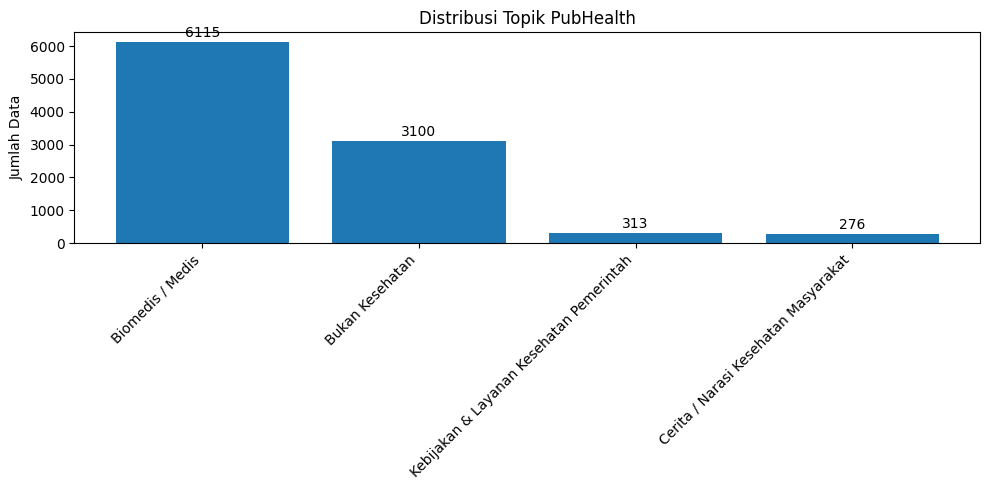

In [ ]:
import matplotlib.pyplot as plt

topic_counts = df["topic"].value_counts()

labels = topic_counts.index
values = topic_counts.values

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v + max(values)*0.01, str(v), ha="center", va="bottom")

plt.title("Distribusi Topik PubHealth")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df_biomed = df[df["topic"] == "Biomedis / Medis"]
df_biomed_selected = df_biomed[["id", "claim", "evidence", "label", "topic"]]

print("Total data Biomedis / Medis:", len(df_biomed_selected))
df_biomed_selected.head(20)


Total data Biomedis / Medis: 6115


,id,claim,evidence,label,topic
2,2,sbrt offers prostate cancer patients high canc...,this news release describes five year outcomes...,mixture,Biomedis / Medis
3,3,study vaccine for breast ovarian cancer has po...,while the story does many things well the over...,true,Biomedis / Medis
4,4,some appendicitis cases may not require emerge...,we really don t understand why only a handful ...,true,Biomedis / Medis
5,5,britain to reveal trial criteria for coronavir...,british regulators will this week reveal appro...,true,Biomedis / Medis
7,7,u s says results encouraging for healthcare de...,the obama administration on thursday reported ...,true,Biomedis / Medis
9,9,poor test results for heart drugs,the story reports no additional cardiovascular...,false,Biomedis / Medis
10,10,opossums kill thousands of ticks each week inh...,what s true some data indicate opossums eat th...,true,Biomedis / Medis
13,13,cancer activist sounds alarm for early testing...,fails to present the nuances associated with t...,false,Biomedis / Medis
14,14,at the end of there were percent fewer federal...,trump said at the end of there were percent fe...,mixture,Biomedis / Medis
15,15,the train carrying gop members of congress to ...,sites like yournewswire gateway pundit and inf...,false,Biomedis / Medis


In [ ]:
df_biomed = df[df["topic"] == "Biomedis / Medis"]
df_biomed_selected = df_biomed[["id", "claim", "evidence", "label", "topic"]]

df_biomed_selected.to_excel("pubhealth_biomed_selected.xlsx",
                            index=False,
                            engine="openpyxl")

print("File berhasil disimpan sebagai pubhealth_biomed_selected.xlsx")

File berhasil disimpan sebagai pubhealth_biomed_selected.xlsx
